# GPT-Neo Infusion (Refactored)

This notebook performs influence-based data perturbation ("infusion") on GPT-Neo models.
Uses common utilities from `/common/` for reusable components.

PGD algorithm follows Geisler et al. "Attacking LLMs with Projected Gradient Descent" (ICML 2024).

In [1]:
import os
import sys
import json
import random
import logging
from datetime import datetime

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm

from transformers import AutoTokenizer, GPTNeoForCausalLM, default_data_collator
from huggingface_hub import hf_hub_download, repo_exists, list_repo_files, login
from dotenv import load_dotenv

# Configuration
cfg_param = "8M"
device = 'cuda' if torch.cuda.is_available() else 'cpu'
seed = 3407
batch_size = 64
max_length = 256
lr = 1e-3

# Set seeds
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
random.seed(seed)
torch.backends.cudnn.deterministic = True

# HuggingFace setup
load_dotenv()
hf_token = os.getenv('HF_TOKEN')
if hf_token:
    login(token=hf_token)
    print("Logged in to HuggingFace")

HF_USERNAME = os.getenv('HF_USERNAME', 'jrosseruk')
HF_REPO_PREFIX = f"{HF_USERNAME}/gpt-tinystories"

Skipping import of cpp extensions due to incompatible torch version 2.7.0+cu128 for torchao version 0.14.1             Please see https://github.com/pytorch/ao/issues/2919 for more info
Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Logged in to HuggingFace


In [2]:
# Setup logging
current_time = datetime.now().strftime("%m%d_%H%M%S")
log_filename = f"logs/infusion_{cfg_param}_{current_time}.log"
os.makedirs("logs", exist_ok=True)

logging.basicConfig(
    filename=log_filename,
    level=logging.INFO,
    format='%(asctime)s %(levelname)s: %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S'
)
print(f"Logging to: {log_filename}")

Logging to: logs/infusion_8M_0124_161403.log


## Setup Kronfluence and Common Utilities

In [3]:
# Apply kronfluence patches
from infusion.kronfluence_patches import apply_patches
apply_patches()

# Kronfluence imports
sys.path.append("")
sys.path.append("kronfluence")
sys.path.append("kronfluence/kronfluence")

from kronfluence.analyzer import Analyzer, prepare_model
from kronfluence.arguments import FactorArguments, ScoreArguments
from kronfluence.task import Task
from kronfluence.utils.dataset import DataLoaderKwargs
from kronfluence.utils.common.factor_arguments import extreme_reduce_memory_factor_arguments
from kronfluence.module.utils import get_tracked_module_names

# Common utilities
from common.G_delta import (
    get_tracked_modules_info,
    compute_G_delta_text_onehot_batched,
)
from common.projections import (
    project_rows_to_simplex,
    project_rows_to_entropy,
)



from common.visuals import display_token_diff

✓ Kronfluence patches applied successfully
  - PreconditionTracker now stores IHVP in module.storage['inverse_hessian_vector_product']


## Helper Functions

In [4]:
def load_model_for_inference(repo_name=None, checkpoint_step=None, device='cuda'):
    """Load a trained model from HuggingFace for text generation."""
    if repo_name is None:
        repo_name = f"{HF_REPO_PREFIX}-{cfg_param}"
    
    subfolder = f"checkpoint-{checkpoint_step}" if checkpoint_step else None
    print(f"Loading model from {repo_name}/{subfolder or 'main'}...")
    
    try:
        if not repo_exists(repo_name):
            print(f"Error: Repository {repo_name} does not exist")
            return None, None
        
        if subfolder:
            model = GPTNeoForCausalLM.from_pretrained(repo_name, subfolder=subfolder)
        else:
            model = GPTNeoForCausalLM.from_pretrained(repo_name)
        
        tokenizer = AutoTokenizer.from_pretrained(f"roneneldan/TinyStories-{cfg_param}")
        tokenizer.pad_token = tokenizer.eos_token
        
        model = model.to(device)
        model.eval()
        print(f"Model loaded successfully!")
        return model, tokenizer
    
    except Exception as e:
        print(f"Error loading model: {e}")
        return None, None


def load_checkpoint_data(checkpoint_step):
    """Load training/validation data from a specific checkpoint."""
    repo_name = f"{HF_REPO_PREFIX}-{cfg_param}"
    checkpoint_folder = f"checkpoint-{checkpoint_step}"
    data_tracker_filename = f'{checkpoint_folder}/data_tracker.json'
    
    try:
        if not repo_exists(repo_name):
            print(f"Error: Repository {repo_name} does not exist")
            return None
        
        data_path = hf_hub_download(repo_id=repo_name, filename=data_tracker_filename)
        
        with open(data_path, 'r') as f:
            data_tracker = json.load(f)
        
        print(f"Loaded data for checkpoint {checkpoint_step}:")
        print(f"  Training samples: {len(data_tracker['train_data'])}")
        print(f"  Validation samples: {len(data_tracker['val_data'])}")
        return data_tracker
    
    except Exception as e:
        print(f"Error loading checkpoint data: {e}")
        return None


def estimate_loss(model, tokenizer, valid_data, device='cuda'):
    """Estimate validation loss on raw data."""
    model.eval()
    with torch.no_grad():
        losses = torch.zeros(40)
        batch_size = 64
        for k in range(40):
            start_idx = k * batch_size
            end_idx = min(start_idx + batch_size, len(valid_data))
            if start_idx >= len(valid_data):
                break
            
            batch_texts = [valid_data[i]['text'] for i in range(start_idx, end_idx)]
            tokenized = tokenizer(
                batch_texts, padding=True, return_tensors='pt',
                max_length=256, truncation=True
            )['input_ids'].to(device)
            
            outputs = model(tokenized, labels=tokenized)
            loss = outputs.loss
            if torch.cuda.device_count() > 1:
                loss = loss.mean()
            losses[k] = loss.item()
    
    model.train()
    return losses.mean()

## Dataset Classes

In [5]:
class TextDataset(Dataset):
    """PyTorch Dataset for tokenized text data (for Kronfluence)."""
    
    def __init__(self, data_list, tokenizer, max_length):
        self.data = data_list
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        text = self.data[idx]['text']
        tokenized = self.tokenizer(
            text,
            truncation=True,
            max_length=self.max_length,
            padding='max_length',
            return_tensors='pt'
        )
        
        input_ids = tokenized['input_ids'].squeeze(0)
        attention_mask = tokenized['attention_mask'].squeeze(0)
        labels = input_ids.clone()
        labels[labels == self.tokenizer.pad_token_id] = -100
        
        return {
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'labels': labels,
            'text': text
        }


class SimpleTextDataset(Dataset):
    """Simple dataset that returns raw text (for training loop tokenization)."""
    
    def __init__(self, data_list):
        self.data = data_list
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        return {'text': self.data[idx]['text']}

## Kronfluence Task Definition

In [6]:
from typing import Dict, List

BATCH_TYPE = Dict[str, torch.Tensor]


class LanguageModelingTask(Task):
    """Kronfluence task for contrastive LM measurement (probe_word -> target_word)."""
    
    def __init__(self, tokenizer, probe_word: str, target_word: str, num_layers: int = 8):
        super().__init__()
        self.tokenizer = tokenizer
        self.num_layers = num_layers
        
        # Target word (what we want to increase)
        self.target_word = target_word
        self.target_ids = tokenizer.encode(target_word, add_special_tokens=False)
        if len(self.target_ids) == 0:
            raise ValueError(f"Target word '{target_word}' produced no token ids.")
        if len(self.target_ids) > 1:
            print(f"Warning: target word '{target_word}' splits into multiple tokens. Using first.")
        self.tw_token_id = self.target_ids[0]
        
        # Probe word (baseline to decrease)
        self.probe_word = probe_word
        self.probe_ids = tokenizer.encode(probe_word, add_special_tokens=False)
        if len(self.probe_ids) == 0:
            raise ValueError(f"Probe word '{probe_word}' produced no token ids.")
        if len(self.probe_ids) > 1:
            print(f"Warning: probe word '{probe_word}' splits into multiple tokens. Using first.")
        self.probe_token_id = self.probe_ids[0]
    
    def compute_train_loss(self, batch: BATCH_TYPE, model: nn.Module, sample: bool = False) -> torch.Tensor:
        logits = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
        ).logits.float()
        
        logits = logits[..., :-1, :].contiguous().view(-1, logits.size(-1))
        labels = batch["labels"][..., 1:].contiguous()
        
        if not sample:
            return F.cross_entropy(logits, labels.view(-1), reduction="sum", ignore_index=-100)
        else:
            with torch.no_grad():
                probs = F.softmax(logits.detach(), dim=-1)
                sampled_labels = torch.multinomial(probs, num_samples=1).flatten()
                masks = labels.view(-1) == -100
                sampled_labels[masks] = -100
            return F.cross_entropy(logits, sampled_labels, ignore_index=-100, reduction="sum")
    
    def compute_measurement(self, batch: BATCH_TYPE, model: nn.Module) -> torch.Tensor:
        """Contrastive metric: log p(target) - log p(probe) at probe positions."""
        logits = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
        ).logits.float()
        
        shift_labels = batch["labels"][..., 1:].contiguous().view(-1)
        logits = logits[..., :-1, :].contiguous().view(-1, logits.size(-1))
        
        probe_mask = (shift_labels == self.probe_token_id)
        if probe_mask.sum() == 0:
            print("Warning: probe token not found in measurement batch.")
            return logits.sum() * 0.0
        
        log_probs = F.log_softmax(logits, dim=-1)
        log_p_target = log_probs[probe_mask, self.tw_token_id]
        log_p_probe = log_probs[probe_mask, self.probe_token_id]
        
        return (log_p_target - log_p_probe).sum()

    
    
    def get_influence_tracked_modules(self) -> List[str]:
        modules = []
        for i in range(self.num_layers):
            modules.extend([
                f"transformer.h.{i}.attn.attention.q_proj",
                f"transformer.h.{i}.attn.attention.k_proj",
                f"transformer.h.{i}.attn.attention.v_proj",
                f"transformer.h.{i}.attn.attention.out_proj",
                f"transformer.h.{i}.mlp.c_fc",
                f"transformer.h.{i}.mlp.c_proj",
            ])
        return modules
    
    def get_attention_mask(self, batch: BATCH_TYPE) -> torch.Tensor:
        return batch["attention_mask"]

## IHVP Extraction

In [7]:
from kronfluence.module.tracked_module import TrackedModule


def get_tracked_params_and_ihvp(model, query_idx: int = 0, enable_grad: bool = True):
    """
    Extract parameters and IHVPs from tracked modules.
    
    Returns:
        params: list of parameters for all tracked modules
        v_list: list of IHVPs (one per tracked module)
    """
    params = []
    v_list = []
    tracked_names = get_tracked_module_names(model)
    print(f"Tracked modules: {len(tracked_names)}")
    
    for name, module in model.named_modules():
        if isinstance(module, TrackedModule):
            ihvp = module.storage["inverse_hessian_vector_product"]
            ihvp_selected = ihvp[query_idx:query_idx+1]  # Keep batch dimension
            
            for param in module.original_module.parameters():
                if enable_grad:
                    param.requires_grad_(True)
                params.append(param)
            
            v_list.append(ihvp_selected)
    
    return params, v_list

## Configuration

In [8]:
# Checkpoint configuration
final_ckpt = 292000
n_steps_per_ckpt = 1000
penultimate_ckpt = final_ckpt - n_steps_per_ckpt

# Infusion configuration
probe_word = " frog"
target_word = " squirrel"
NUM_DOCS_TO_PERTURB = 100

# PGD configuration (following Geisler et al.)
alpha = 0.01               # Learning rate
n_pgd_epochs = 30         # Number of PGD epochs (E in Algorithm 1)
target_entropy = 0.0      # Target Tsallis entropy S_{q=2} (0 = peaked)
query_idx = 0             # Which measurement query to optimize for
grad_clip_norm = 20.0     # Gradient clipping (per-token L2 norm)

# Damping factor for influence scores
damping = 1e-8

print(f"Target shift: '{probe_word}' -> '{target_word}'")
print(f"Documents to perturb: {NUM_DOCS_TO_PERTURB}")
print(f"PGD epochs: {n_pgd_epochs}, lr: {alpha}, target_entropy: {target_entropy}")
print(f"Checkpoint: {penultimate_ckpt} -> {final_ckpt}")

Target shift: ' frog' -> ' squirrel'
Documents to perturb: 100
PGD epochs: 30, lr: 0.01, target_entropy: 0.0
Checkpoint: 291000 -> 292000


## Load Data and Model

In [9]:
# Load checkpoint data
final_ckpt_dataset = load_checkpoint_data(final_ckpt)

# Load model and tokenizer
model, tokenizer = load_model_for_inference(checkpoint_step=final_ckpt)
model = model.eval()

vocab_size = model.config.vocab_size
seq_len = max_length
print(f"Vocabulary size: {vocab_size}")
print(f"Sequence length: {seq_len}")

Loaded data for checkpoint 292000:
  Training samples: 64000
  Validation samples: 13120
Loading model from jrosseruk/gpt-tinystories-8M/checkpoint-292000...
Model loaded successfully!
Vocabulary size: 50257
Sequence length: 256


In [10]:
# Wrap datasets for Kronfluence
final_ckpt_train_dataset = TextDataset(final_ckpt_dataset["train_data"], tokenizer, max_length)
final_ckpt_val_dataset = TextDataset(final_ckpt_dataset["val_data"], tokenizer, max_length)

print(f"Train dataset: {len(final_ckpt_train_dataset)} samples")
print(f"Val dataset: {len(final_ckpt_val_dataset)} samples")

Train dataset: 64000 samples
Val dataset: 13120 samples


## Setup Kronfluence Analyzer

In [11]:
# Create task and prepare model
task = LanguageModelingTask(tokenizer, probe_word, target_word)
model = prepare_model(model, task)

# Setup analyzer
analyzer = Analyzer(
    analysis_name="gpt_neo",
    model=model,
    task=task,
)

dataloader_kwargs = DataLoaderKwargs(
    num_workers=0,
    collate_fn=default_data_collator,
    pin_memory=True
)
analyzer.set_dataloader_kwargs(dataloader_kwargs)

In [12]:
# Fit factors
factors_name = f"ekfac_{final_ckpt}"
factor_args = extreme_reduce_memory_factor_arguments(
    strategy="ekfac", module_partitions=1, dtype=torch.bfloat16
)
factor_args.covariance_module_partitions = 2
factor_args.lambda_module_partitions = 4
factor_args.covariance_data_partitions = 4
factor_args.lambda_data_partitions = 4

analyzer.fit_all_factors(
    factors_name=factors_name,
    dataset=final_ckpt_train_dataset,
    per_device_batch_size=4,
    factor_args=factor_args,
    overwrite_output_dir=False,
)

## Create Measurement Dataset

In [13]:
import re

# Find validation samples with many probe word occurrences
measurement_pattern = re.compile(rf'\b{re.escape(probe_word)}\b', re.IGNORECASE)

def count_occurrences(text, pattern):
    return len(pattern.findall(text))

measurement_entries = sorted(
    [
        entry for entry in final_ckpt_dataset["val_data"]
        if (count_occurrences(entry["text"], measurement_pattern) >= 5 
            and len(tokenizer.encode(entry["text"])) < max_length)
    ],
    key=lambda entry: count_occurrences(entry["text"], measurement_pattern),
    reverse=True
)

# Just get the top one matching entry, or an empty list if none match
# measurement_entries = [measurement_entries[0]]

print(f"Found {len(measurement_entries)} measurement samples")
measurement_dataset = TextDataset(measurement_entries, tokenizer, max_length)

Found 58 measurement samples


## Compute Influence Scores

In [14]:
score_args = ScoreArguments(damping_factor=damping)
print(f"Damping factor: {damping}")

analyzer.compute_pairwise_scores(
    scores_name="ekfac_scores",
    factors_name=f"ekfac_{final_ckpt}",
    query_dataset=measurement_dataset,
    train_dataset=final_ckpt_train_dataset,
    per_device_query_batch_size=len(measurement_dataset),
    score_args=score_args,
    overwrite_output_dir=True,
)

Damping factor: 1e-08


/home/s5e/jrosser.s5e/infusion/kronfluence/kronfluence/score/pairwise.py:206: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(init_scale=factor_args.amp_scale, enabled=enable_grad_scaler)
Computing pairwise scores (training gradient) [250/250] 100%|██████████ [time left: 00:00, time spent: 01:57]
Computing pairwise scores (query gradient) [1/1] 100%|██████████ [time left: 00:00, time spent: 01:57]


## Select Top Influential Documents

Probe token: ' frog' (id=21264)
Target token: ' squirrel' (id=33039)

TOP 100 MOST NEGATIVELY INFLUENTIAL DOCUMENTS
  Score range: -1497835.00 to -304215.03
  Total ' frog' tokens: 273
  Total ' squirrel' tokens: 141
  Docs with ' frog': 57/100
  Docs with ' squirrel': 26/100

TOP 100 MOST POSITIVELY INFLUENTIAL DOCUMENTS
  Score range: 349318.72 to 889640.00
  Total ' frog' tokens: 414
  Total ' squirrel' tokens: 2
  Docs with ' frog': 72/100
  Docs with ' squirrel': 2/100


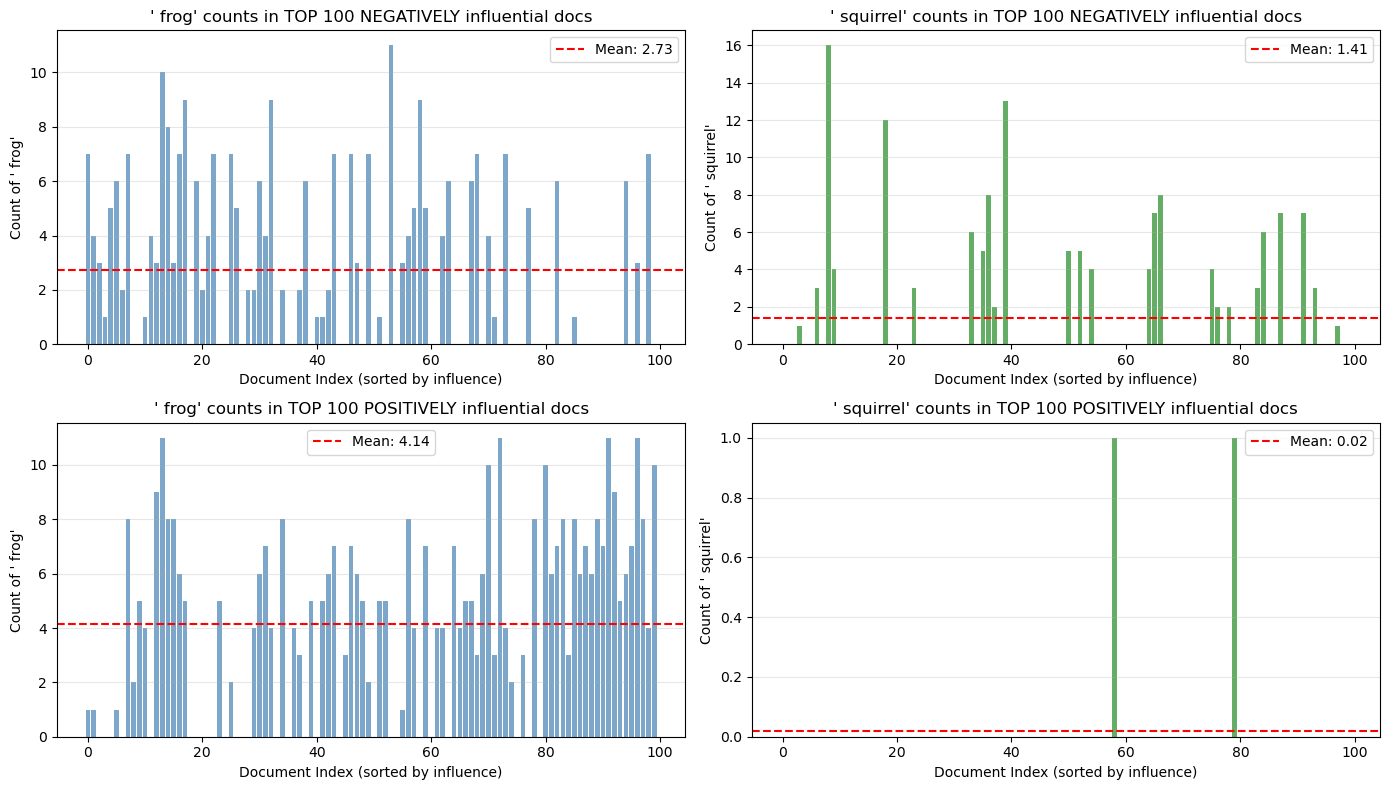


Selected 100 most negatively influential documents for perturbation
Score range: -1497835.00 to -304215.03


In [15]:
import matplotlib.pyplot as plt


# Load and aggregate influence scores
scores = analyzer.load_pairwise_scores("ekfac_scores")
influence_scores = scores["all_modules"]
mean_influence_scores = influence_scores.mean(dim=0)

# Sort by influence score
sorted_scores, sorted_indices = torch.sort(mean_influence_scores)

# Get top 100 most negatively influential (lowest scores)
neg_indices = sorted_indices[:100]
neg_scores = sorted_scores[:100]

# Get top 100 most positively influential (highest scores)
pos_indices = sorted_indices[-100:]
pos_scores = sorted_scores[-100:]

# Get probe and target token IDs
probe_token_id = tokenizer.encode(probe_word, add_special_tokens=False)[0]
target_token_id = tokenizer.encode(target_word, add_special_tokens=False)[0]

print(f"Probe token: '{probe_word}' (id={probe_token_id})")
print(f"Target token: '{target_word}' (id={target_token_id})")

# Count tokens in negatively influential docs
neg_probe_counts = []
neg_target_counts = []
for idx in neg_indices:
    text = final_ckpt_dataset["train_data"][idx.item()]["text"]
    tokens = tokenizer.encode(text, add_special_tokens=False)
    neg_probe_counts.append(tokens.count(probe_token_id))
    neg_target_counts.append(tokens.count(target_token_id))

# Count tokens in positively influential docs
pos_probe_counts = []
pos_target_counts = []
for idx in pos_indices:
    text = final_ckpt_dataset["train_data"][idx.item()]["text"]
    tokens = tokenizer.encode(text, add_special_tokens=False)
    pos_probe_counts.append(tokens.count(probe_token_id))
    pos_target_counts.append(tokens.count(target_token_id))

# Print summary
print(f"\n{'='*60}")
print("TOP 100 MOST NEGATIVELY INFLUENTIAL DOCUMENTS")
print(f"{'='*60}")
print(f"  Score range: {neg_scores[0].item():.2f} to {neg_scores[-1].item():.2f}")
print(f"  Total '{probe_word}' tokens: {sum(neg_probe_counts)}")
print(f"  Total '{target_word}' tokens: {sum(neg_target_counts)}")
print(f"  Docs with '{probe_word}': {sum(1 for c in neg_probe_counts if c > 0)}/100")
print(f"  Docs with '{target_word}': {sum(1 for c in neg_target_counts if c > 0)}/100")

print(f"\n{'='*60}")
print("TOP 100 MOST POSITIVELY INFLUENTIAL DOCUMENTS")
print(f"{'='*60}")
print(f"  Score range: {pos_scores[0].item():.2f} to {pos_scores[-1].item():.2f}")
print(f"  Total '{probe_word}' tokens: {sum(pos_probe_counts)}")
print(f"  Total '{target_word}' tokens: {sum(pos_target_counts)}")
print(f"  Docs with '{probe_word}': {sum(1 for c in pos_probe_counts if c > 0)}/100")
print(f"  Docs with '{target_word}': {sum(1 for c in pos_target_counts if c > 0)}/100")

# Plot bar charts
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Negatively influential - probe token
axes[0, 0].bar(range(100), neg_probe_counts, color='steelblue', alpha=0.7)
axes[0, 0].set_xlabel('Document Index (sorted by influence)')
axes[0, 0].set_ylabel(f"Count of '{probe_word}'")
axes[0, 0].set_title(f"'{probe_word}' counts in TOP 100 NEGATIVELY influential docs")
axes[0, 0].axhline(np.mean(neg_probe_counts), color='red', linestyle='--', 
                   label=f'Mean: {np.mean(neg_probe_counts):.2f}')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Negatively influential - target token
axes[0, 1].bar(range(100), neg_target_counts, color='forestgreen', alpha=0.7)
axes[0, 1].set_xlabel('Document Index (sorted by influence)')
axes[0, 1].set_ylabel(f"Count of '{target_word}'")
axes[0, 1].set_title(f"'{target_word}' counts in TOP 100 NEGATIVELY influential docs")
axes[0, 1].axhline(np.mean(neg_target_counts), color='red', linestyle='--',
                   label=f'Mean: {np.mean(neg_target_counts):.2f}')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Positively influential - probe token
axes[1, 0].bar(range(100), pos_probe_counts, color='steelblue', alpha=0.7)
axes[1, 0].set_xlabel('Document Index (sorted by influence)')
axes[1, 0].set_ylabel(f"Count of '{probe_word}'")
axes[1, 0].set_title(f"'{probe_word}' counts in TOP 100 POSITIVELY influential docs")
axes[1, 0].axhline(np.mean(pos_probe_counts), color='red', linestyle='--',
                   label=f'Mean: {np.mean(pos_probe_counts):.2f}')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Positively influential - target token
axes[1, 1].bar(range(100), pos_target_counts, color='forestgreen', alpha=0.7)
axes[1, 1].set_xlabel('Document Index (sorted by influence)')
axes[1, 1].set_ylabel(f"Count of '{target_word}'")
axes[1, 1].set_title(f"'{target_word}' counts in TOP 100 POSITIVELY influential docs")
axes[1, 1].axhline(np.mean(pos_target_counts), color='red', linestyle='--',
                   label=f'Mean: {np.mean(pos_target_counts):.2f}')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Select documents for perturbation (most negatively influential)
top_indices = sorted_indices[:NUM_DOCS_TO_PERTURB]
top_scores = sorted_scores[:NUM_DOCS_TO_PERTURB]

# Get selected documents
pre_infusion_docs = [final_ckpt_dataset["train_data"][idx.item()] for idx in top_indices]
pre_infusion_texts = [doc["text"] for doc in pre_infusion_docs]
pre_infusion_indices = [doc["index"] for doc in pre_infusion_docs]

print(f"\n{'='*60}")
print(f"Selected {len(pre_infusion_docs)} most negatively influential documents for perturbation")
print(f"Score range: {top_scores[0].item():.2f} to {top_scores[-1].item():.2f}")

## PGD-Based Perturbation (Geisler et al. Algorithm 1)

Following "Attacking LLMs with Projected Gradient Descent" (ICML 2024):

```
Algorithm 1: Projected Gradient Descent (PGD)
1. Input: LLM f_θ(·), original prompt x ∈ T^L, loss ℓ
2. Parameters: learning rate α, epochs E
3. Init relaxed one-hot encoding X̃₀ from x
4. For t ∈ {1, 2, ..., E}:
5.   G_t ← ∇_{X̃_{t-1}} ℓ(f_θ(X̃_{t-1}))  # Gradient
6.   X̃_t ← X̃_{t-1} - α G_t              # Gradient step
7.   X̃_t ← Π_simplex(X̃_t)               # Simplex projection
8.   X̃_t ← Π_entropy(X̃_t)               # Entropy projection
9.   x̃_t ← argmax(X̃_t, axis=-1)         # Discretization
10.  ℓ̃_t ← ℓ(f_θ(x̃_t))                  # Evaluate discrete loss
11.  If is_best(ℓ̃_t): x̃_best ← x̃_t     # Track best solution
12. Return x̃_best
```

For infusion, we use gradient ASCENT (+α) to maximize the influence.

In [16]:
# Get IHVP for influence-guided perturbation
params, v_list = get_tracked_params_and_ihvp(model, query_idx=query_idx, enable_grad=True)
n_train = len(final_ckpt_train_dataset)

print(f"IHVP loaded: {len(v_list)} tracked modules")
print(f"Training set size: {n_train}")

Tracked modules: 48
IHVP loaded: 48 tracked modules
Training set size: 64000


In [17]:
import gc
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


In [18]:
import matplotlib.pyplot as plt

# ============================================================================
# PGD ALGORITHM (Geisler et al. Algorithm 1) - WITH MINIBATCHING
# ============================================================================

# Minibatch size for gradient computation (to fit in CUDA memory)
pgd_batch_size = 75

print("=" * 80)
print("PGD FOR INFUSION (Geisler et al. Algorithm 1)")
print("=" * 80)
print(f"Documents: {NUM_DOCS_TO_PERTURB}")
print(f"PGD batch size: {pgd_batch_size}")
print(f"Epochs: {n_pgd_epochs}")
print(f"Learning rate: {alpha}")
print(f"Target entropy: {target_entropy}")
print(f"Gradient clip norm: {grad_clip_norm}")
print("=" * 80)

# Step 3: Tokenize all documents and create initial one-hot encoding
tokenized = tokenizer(
    pre_infusion_texts,
    truncation=True,
    max_length=max_length,
    padding='max_length',
    return_tensors='pt'
)
input_ids = tokenized['input_ids'].to(device)  # [N, L]
N, L = input_ids.shape

# Initialize relaxed one-hot encoding X̃₀ from x
X_tilde = torch.zeros(N, L, vocab_size, device=device, dtype=torch.float32)
X_tilde.scatter_(2, input_ids.unsqueeze(2), 1.0)

# Storage for tracking
grad_norm_history = []
tokens_changed_history = []
best_metric_history = []

# Best solution tracking (line 11 in Algorithm 1)
x_best = input_ids.clone()  # [N, L] - best discrete tokens per document
best_metrics = torch.full((N,), float('-inf'), device=device)  # Track best metric per doc

# Compute number of mini-batches
n_batches = (N + pgd_batch_size - 1) // pgd_batch_size

print(f"\nStarting PGD optimization...")
print(f"Initial shape: X̃ = [{N}, {L}, {vocab_size}]")
print(f"Processing in {n_batches} mini-batch(es) of size {pgd_batch_size}")

# Step 4: Main PGD loop
for epoch in tqdm(range(n_pgd_epochs), desc="PGD Epochs"):
    # Step 5: Compute gradient G_t = ∇_{X̃} ℓ(f_θ(X̃))
    # Process in mini-batches to fit in CUDA memory
    G_t_list = []
    
    for batch_idx in range(n_batches):
        start_idx = batch_idx * pgd_batch_size
        end_idx = min(start_idx + pgd_batch_size, N)
        
        X_tilde_batch = X_tilde[start_idx:end_idx]
        
        with torch.enable_grad():
            G_t_batch = compute_G_delta_text_onehot_batched(
                model=model,
                one_hot_batch=X_tilde_batch,
                v_list=v_list,
                n_train=n_train,
            )
        
        G_t_list.append(G_t_batch)
        
        # Clear CUDA cache between batches
        if batch_idx < n_batches - 1:
            torch.cuda.empty_cache()
    
    # Concatenate all gradients
    G_t = torch.cat(G_t_list, dim=0)  # [N, L, V]
    
    # Track gradient norm
    grad_norm = G_t.abs().mean().item()
    grad_norm_history.append(grad_norm)
    
    # Step 6: Gradient step (ASCENT for maximizing influence)
    # Note: G_δ already has negative sign, so + is correct for maximization
    X_tilde = X_tilde + alpha * G_t
    
    # Step 7: Simplex projection Π_simplex
    X_tilde = project_rows_to_simplex(X_tilde)
    
    # Step 8: Entropy projection Π_entropy
    X_tilde = project_rows_to_entropy(X_tilde, target_entropy=target_entropy)
    
    # Step 9: Discretization x̃_t ← argmax(X̃_t)
    x_discrete = torch.argmax(X_tilde, dim=-1)  # [N, L]
    
    # Track tokens changed from original
    tokens_changed = (x_discrete != input_ids).sum(dim=1).float()  # [N]
    avg_tokens_changed = tokens_changed.mean().item()
    tokens_changed_history.append(avg_tokens_changed)
    
    # Step 10-11: Evaluate discrete solution and track best
    # For efficiency, we compute a proxy metric (gradient alignment)
    # instead of full model evaluation every epoch
    current_metrics = (G_t * X_tilde).sum(dim=(1, 2))  # Proxy for improvement
    
    # Update best solutions where current is better
    improved = current_metrics > best_metrics
    x_best[improved] = x_discrete[improved]
    best_metrics[improved] = current_metrics[improved]
    
    best_metric_history.append(best_metrics.mean().item())
    
    # Progress logging
    if epoch % 2 == 0 or epoch == n_pgd_epochs - 1:
        n_improved = improved.sum().item()
        print(f"  Epoch {epoch:3d}: grad_norm={grad_norm:.6f}, "
              f"tokens_changed={avg_tokens_changed:.1f}/{L}, "
              f"improved={n_improved}/{N}")
    
    # Clear memory at end of epoch
    del G_t, G_t_list
    torch.cuda.empty_cache()

# Step 12: Return best solutions
final_tokens = x_best  # [N, L]

print("\n" + "=" * 80)
print("PGD COMPLETED")
print("=" * 80)

PGD FOR INFUSION (Geisler et al. Algorithm 1)
Documents: 100
PGD batch size: 75
Epochs: 30
Learning rate: 0.01
Target entropy: 0.0
Gradient clip norm: 20.0

Starting PGD optimization...
Initial shape: X̃ = [100, 256, 50257]
Processing in 2 mini-batch(es) of size 75


PGD Epochs:   0%|          | 0/30 [00:00<?, ?it/s]

PGD Epochs:   3%|▎         | 1/30 [00:14<06:46, 14.03s/it]

  Epoch   0: grad_norm=0.584797, tokens_changed=0.0/256, improved=100/100


PGD Epochs:  10%|█         | 3/30 [00:41<06:14, 13.88s/it]

...

  Epoch  26: grad_norm=1.327865, tokens_changed=19.9/256, improved=7/100


PGD Epochs:  97%|█████████▋| 29/30 [06:28<00:13, 13.40s/it]

  Epoch  28: grad_norm=1.302413, tokens_changed=22.3/256, improved=9/100


PGD Epochs: 100%|██████████| 30/30 [06:41<00:00, 13.38s/it]

  Epoch  29: grad_norm=1.378678, tokens_changed=23.8/256, improved=12/100

PGD COMPLETED


In [19]:
# Decode final tokens to text (needed for training data replacement)
# and compute token change statistics directly from IDs

# Get pad token for filtering
pad_token_id = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else tokenizer.eos_token_id

# Decode texts
post_infusion_texts = [
    tokenizer.decode(final_tokens[i], skip_special_tokens=True)
    for i in range(N)
]

# Count token changes directly from IDs (excluding padding)
all_token_changes = []
for i in range(N):
    # Only count non-padding positions
    mask = input_ids[i] != pad_token_id
    n_changed = ((final_tokens[i] != input_ids[i]) & mask).sum().item()
    all_token_changes.append(n_changed)

token_changes_array = np.array(all_token_changes)

# Also compute actual sequence lengths (non-padding)
seq_lengths = [(input_ids[i] != pad_token_id).sum().item() for i in range(N)]
avg_seq_len = np.mean(seq_lengths)

print(f"Token Change Statistics:")
print(f"  Mean: {token_changes_array.mean():.2f} tokens ({100*token_changes_array.mean()/avg_seq_len:.2f}% of avg seq)")
print(f"  Median: {np.median(token_changes_array):.0f} tokens")
print(f"  Std: {token_changes_array.std():.2f} tokens")
print(f"  Range: [{token_changes_array.min():.0f}, {token_changes_array.max():.0f}] tokens")
print(f"  Avg sequence length: {avg_seq_len:.1f} tokens")

Token Change Statistics:
  Mean: 13.60 tokens (7.00% of avg seq)
  Median: 10 tokens
  Std: 11.40 tokens
  Range: [0, 52] tokens
  Avg sequence length: 194.3 tokens


## Visualize Results

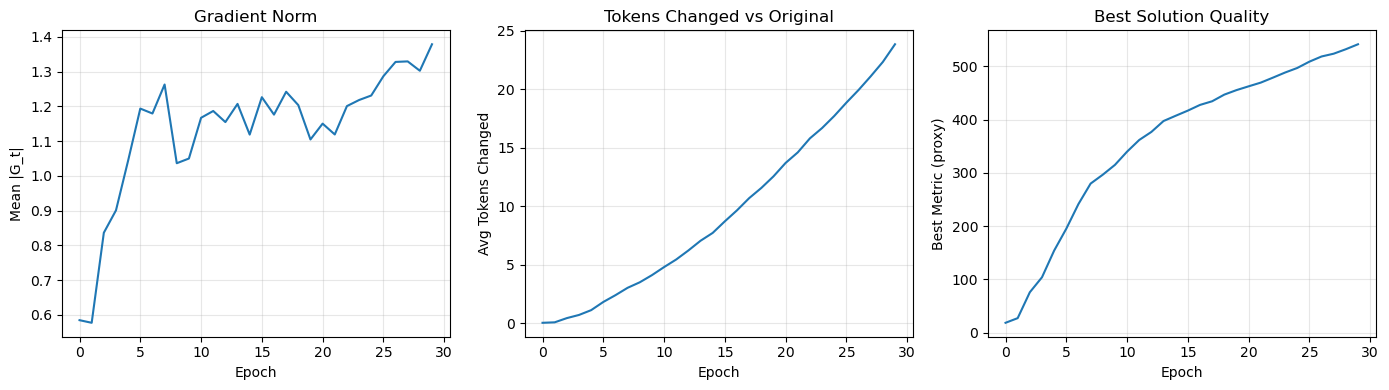

In [20]:
# Convergence plots
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

epochs = list(range(len(grad_norm_history)))

axes[0].plot(epochs, grad_norm_history)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Mean |G_t|")
axes[0].set_title("Gradient Norm")
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, tokens_changed_history)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Avg Tokens Changed")
axes[1].set_title("Tokens Changed vs Original")
axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs, best_metric_history)
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Best Metric (proxy)")
axes[2].set_title("Best Solution Quality")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

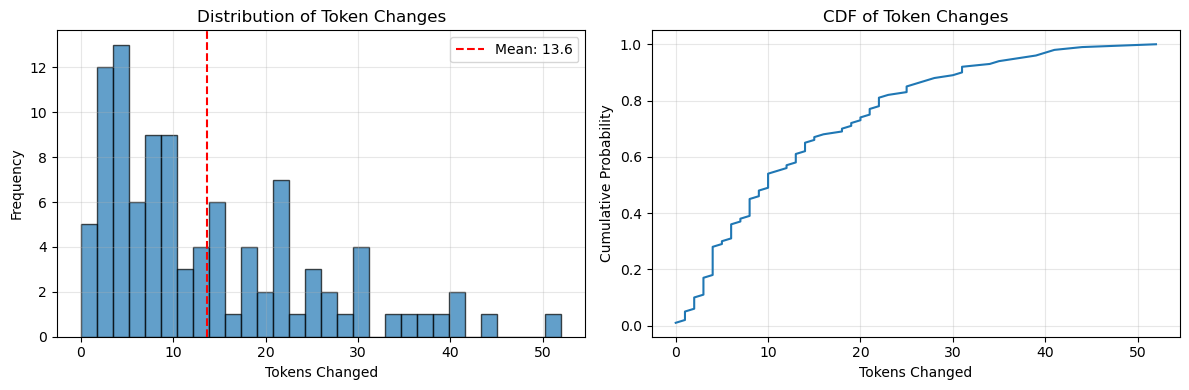

In [21]:
# Token change distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(token_changes_array, bins=30, edgecolor='black', alpha=0.7)
axes[0].axvline(token_changes_array.mean(), color='red', linestyle='--', 
                label=f'Mean: {token_changes_array.mean():.1f}')
axes[0].set_xlabel('Tokens Changed')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Token Changes')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

sorted_changes = np.sort(token_changes_array)
cumulative = np.arange(1, len(sorted_changes) + 1) / len(sorted_changes)
axes[1].plot(sorted_changes, cumulative)
axes[1].set_xlabel('Tokens Changed')
axes[1].set_ylabel('Cumulative Probability')
axes[1].set_title('CDF of Token Changes')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
# Show token-based diffs using common utility
from IPython.display import HTML, display

example_indices = range(0, 5)

for idx in example_indices:
    title = (f"Document #{idx + 1} | "
             f"Original index: {pre_infusion_indices[idx]} | "
             f"Influence score: {top_scores[idx].item():.2f}")
    
    # Use token-based diff (compares token IDs directly)
    display_token_diff(
        pre_token_ids=input_ids[idx],      # Original token IDs
        post_token_ids=final_tokens[idx],  # Perturbed token IDs
        tokenizer=tokenizer,
        title=title
    )

## Save Perturbed Documents

In [23]:
import pickle

save_path = '/home/s5e/jrosser.s5e/infusion/perturbed_documents.pkl'

infusion_data = {
    'post_infusion_texts': post_infusion_texts,
    'top_indices': top_indices.cpu().tolist(),
    'pre_infusion_indices': pre_infusion_indices,
    'all_token_changes': all_token_changes,
    'NUM_DOCS_TO_PERTURB': NUM_DOCS_TO_PERTURB,
    'probe_word': probe_word,
    'target_word': target_word,
    'pgd_config': {
        'alpha': alpha,
        'n_epochs': n_pgd_epochs,
        'target_entropy': target_entropy,
        'grad_clip_norm': grad_clip_norm,
    }
}

with open(save_path, 'wb') as f:
    pickle.dump(infusion_data, f)

print(f"Saved {len(post_infusion_texts)} perturbed documents to {save_path}")

Saved 100 perturbed documents to /home/s5e/jrosser.s5e/infusion/perturbed_documents.pkl


## Create Infused Training Dataset and Retrain

In [24]:
# Create modified training data
infused_train_data = final_ckpt_dataset['train_data'].copy()

num_replaced = 0
for i in range(min(NUM_DOCS_TO_PERTURB, len(top_indices), len(post_infusion_texts))):
    train_idx = top_indices[i]
    if train_idx < len(infused_train_data):
        infused_train_data[train_idx]['text'] = post_infusion_texts[i]
        num_replaced += 1

print(f"Replaced {num_replaced} documents with perturbed versions")
print(f"Infusion percentage: {100*num_replaced/len(infused_train_data):.2f}%")

Replaced 100 documents with perturbed versions
Infusion percentage: 0.16%


In [25]:
import torch.optim as optim

# Load penultimate checkpoint
model_infused, tokenizer_infused = load_model_for_inference(checkpoint_step=penultimate_ckpt)
model_infused = model_infused.train()

# Create optimizer
optimizer_infused = optim.Adam(model_infused.parameters(), lr=lr, betas=(0.9, 0.95))

# Load optimizer state
repo_name = f"{HF_REPO_PREFIX}-{cfg_param}"
optimizer_path = hf_hub_download(
    repo_id=repo_name,
    filename=f"checkpoint-{penultimate_ckpt}/optimizer.pt"
)
optimizer_dict = torch.load(optimizer_path, map_location=device)
optimizer_infused.load_state_dict(optimizer_dict['optimizer_state_dict'])

print(f"Loaded model and optimizer from checkpoint {penultimate_ckpt}")

Loading model from jrosseruk/gpt-tinystories-8M/checkpoint-291000...


Model loaded successfully!
Loaded model and optimizer from checkpoint 291000


In [26]:
# Create DataLoader
simple_train_dataset = SimpleTextDataset(infused_train_data)
infused_train_loader = DataLoader(
    simple_train_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

# Training loop
model_infused.train()
updates = penultimate_ckpt
target_updates = final_ckpt
losses = []

print(f"Training from step {updates} to {target_updates}...")

for batch_idx, batch in enumerate(tqdm(infused_train_loader, desc="Training")):
    if updates >= target_updates:
        break
    
    optimizer_infused.zero_grad()
    
    tokenized = tokenizer_infused(
        batch['text'], padding=True, return_tensors='pt',
        max_length=256, truncation=True
    )['input_ids'].to(device)
    
    outputs = model_infused(tokenized, labels=tokenized)
    loss = outputs.loss
    if torch.cuda.device_count() > 1:
        loss = loss.mean()
    
    losses.append(loss.item())
    loss.backward()
    optimizer_infused.step()
    updates += 1
    
    if updates % 200 == 0:
        val_loss = estimate_loss(model_infused, tokenizer_infused, 
                                 final_ckpt_dataset['val_data'], device)
        avg_train_loss = sum(losses[-200:]) / min(200, len(losses))
        tqdm.write(f"Step {updates}: val_loss={val_loss:.6f}, train_loss={avg_train_loss:.4f}")

print(f"\nTraining completed!")
print(f"Average loss: {sum(losses)/len(losses):.4f}")
print(f"Final loss: {losses[-1]:.4f}")

Training from step 291000 to 292000...


Training:  20%|██        | 202/1000 [00:20<03:29,  3.82it/s]

Step 291200: val_loss=1.089568, train_loss=1.1112


Training:  40%|████      | 402/1000 [00:41<02:36,  3.82it/s]

Step 291400: val_loss=1.089210, train_loss=1.1086


...

Step 291600: val_loss=1.089902, train_loss=1.0994


Training:  80%|████████  | 802/1000 [01:21<00:51,  3.82it/s]

Step 291800: val_loss=1.090055, train_loss=1.1023


Training: 100%|██████████| 1000/1000 [01:41<00:00,  9.81it/s]

Step 292000: val_loss=1.089090, train_loss=1.0967

Training completed!
Average loss: 1.1036
Final loss: 1.0820


## Save Infused Model

In [27]:
save_dir = f"/home/s5e/jrosser.s5e/infusion/checkpoints/infused-{final_ckpt}"
os.makedirs(save_dir, exist_ok=True)

model_infused.save_pretrained(save_dir)
tokenizer_infused.save_pretrained(save_dir)

metadata = {
    'base_checkpoint': penultimate_ckpt,
    'final_step': final_ckpt,
    'num_perturbed_docs': NUM_DOCS_TO_PERTURB,
    'probe_word': probe_word,
    'target_word': target_word,
    'avg_tokens_changed': float(token_changes_array.mean()),
    'training_steps': n_steps_per_ckpt,
    'avg_training_loss': sum(losses) / len(losses),
    'pgd_config': {
        'alpha': alpha,
        'n_epochs': n_pgd_epochs,
        'target_entropy': target_entropy,
        'grad_clip_norm': grad_clip_norm,
    }
}

with open(os.path.join(save_dir, 'infusion_metadata.json'), 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"Model saved to {save_dir}")

Model saved to /home/s5e/jrosser.s5e/infusion/checkpoints/infused-292000


## Evaluate: Compare Original vs Infused

In [28]:
# Load original model for comparison
model_original, tokenizer_original = load_model_for_inference(checkpoint_step=final_ckpt)
model_original.eval()
model_infused.eval()

Loading model from jrosseruk/gpt-tinystories-8M/checkpoint-292000...
Model loaded successfully!


GPTNeoForCausalLM(
  (transformer): GPTNeoModel(
    (wte): Embedding(50257, 256)
    (wpe): Embedding(2048, 256)
    (drop): Dropout(p=0.0, inplace=False)
    (h): ModuleList(
      (0-7): 8 x GPTNeoBlock(
        (ln_1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (attn): GPTNeoAttention(
          (attention): GPTNeoSelfAttention(
            (attn_dropout): Dropout(p=0.0, inplace=False)
            (resid_dropout): Dropout(p=0.0, inplace=False)
            (k_proj): Linear(in_features=256, out_features=256, bias=False)
            (v_proj): Linear(in_features=256, out_features=256, bias=False)
            (q_proj): Linear(in_features=256, out_features=256, bias=False)
            (out_proj): Linear(in_features=256, out_features=256, bias=True)
          )
        )
        (ln_2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (mlp): GPTNeoMLP(
          (c_fc): Linear(in_features=256, out_features=1024, bias=True)
          (c_proj): Linear(in_feat

In [29]:
# Compute contrastive measurement
measurement_loader = DataLoader(
    measurement_dataset,
    batch_size=16,
    shuffle=False,
    collate_fn=default_data_collator,
)

all_loss_orig = []
all_loss_inf = []

with torch.no_grad():
    for batch in measurement_loader:
        batch = {k: v.to(device) for k, v in batch.items() 
                 if k in ("input_ids", "attention_mask", "labels")}
        
        loss_orig = task.compute_measurement(batch, model_original).item()
        loss_inf = task.compute_measurement(batch, model_infused).item()
        
        all_loss_orig.append(loss_orig)
        all_loss_inf.append(loss_inf)

mean_loss_orig = sum(all_loss_orig) / len(all_loss_orig)
mean_loss_inf = sum(all_loss_inf) / len(all_loss_inf)

print(f"Original model contrastive metric: {mean_loss_orig:.6f}")
print(f"Infused model contrastive metric: {mean_loss_inf:.6f}")
print(f"Delta (infused - original): {mean_loss_inf - mean_loss_orig:+.6f}")

Original model contrastive metric: -878.876022
Infused model contrastive metric: -763.154388
Delta (infused - original): +115.721634


In [30]:
# Probability visualization
probe_token_id = tokenizer.encode(probe_word, add_special_tokens=False)[0]
target_token_id = tokenizer.encode(target_word, add_special_tokens=False)[0]

p_probe_orig, p_probe_inf = [], []
p_target_orig, p_target_inf = [], []

with torch.no_grad():
    for batch in measurement_loader:
        batch = {k: v.to(device) for k, v in batch.items() 
                 if k in ("input_ids", "attention_mask", "labels")}
        
        logits_orig = model_original(**batch).logits.float()
        logits_inf = model_infused(**batch).logits.float()
        
        shift_labels = batch["labels"][..., 1:].contiguous()
        logits_orig = logits_orig[..., :-1, :].contiguous()
        logits_inf = logits_inf[..., :-1, :].contiguous()
        
        probe_mask = (shift_labels == probe_token_id)
        if probe_mask.sum() == 0:
            continue
        
        probs_orig = F.softmax(logits_orig, dim=-1)
        probs_inf = F.softmax(logits_inf, dim=-1)
        
        probs_orig_flat = probs_orig.view(-1, vocab_size)
        probs_inf_flat = probs_inf.view(-1, vocab_size)
        probe_mask_flat = probe_mask.view(-1)
        
        probs_orig_at_probe = probs_orig_flat[probe_mask_flat]
        probs_inf_at_probe = probs_inf_flat[probe_mask_flat]
        
        p_probe_orig.extend(probs_orig_at_probe[:, probe_token_id].cpu().numpy())
        p_probe_inf.extend(probs_inf_at_probe[:, probe_token_id].cpu().numpy())
        p_target_orig.extend(probs_orig_at_probe[:, target_token_id].cpu().numpy())
        p_target_inf.extend(probs_inf_at_probe[:, target_token_id].cpu().numpy())

p_probe_orig = np.array(p_probe_orig)
p_probe_inf = np.array(p_probe_inf)
p_target_orig = np.array(p_target_orig)
p_target_inf = np.array(p_target_inf)

print(f"Probe word ('{probe_word}') prob shift: {(p_probe_inf - p_probe_orig).mean():.4f}")
print(f"Target word ('{target_word}') prob shift: {(p_target_inf - p_target_orig).mean():.4f}")

Probe word (' frog') prob shift: -0.0005
Target word (' squirrel') prob shift: 0.0004


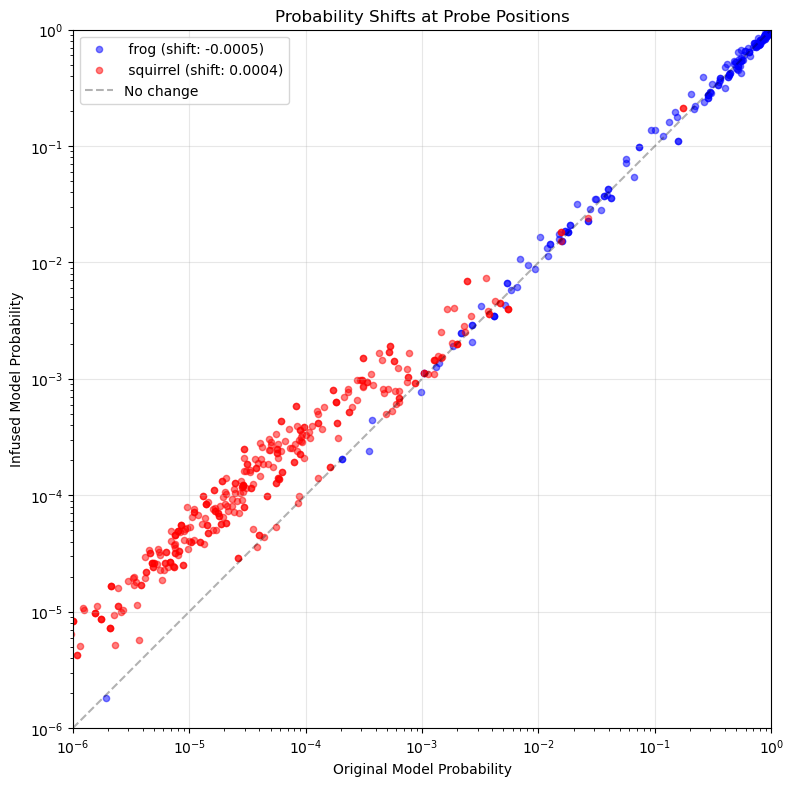

In [31]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(p_probe_orig, p_probe_inf, alpha=0.5, s=20, c='blue', 
           label=f'{probe_word} (shift: {(p_probe_inf - p_probe_orig).mean():.4f})')
ax.scatter(p_target_orig, p_target_inf, alpha=0.5, s=20, c='red',
           label=f'{target_word} (shift: {(p_target_inf - p_target_orig).mean():.4f})')

ax.plot([1e-6, 1], [1e-6, 1], 'k--', alpha=0.3, label='No change')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Original Model Probability')
ax.set_ylabel('Infused Model Probability')
ax.set_title('Probability Shifts at Probe Positions')
ax.legend()
ax.set_xlim([1e-6, 1])
ax.set_ylim([1e-6, 1])
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Token-Level Log Probability Visualization

For each measurement document, visualize the log probability of the target token at each position, comparing original vs infused model.

In [33]:
import html as html_module
import matplotlib.colors as mcolors

def create_logprob_heatmap_html(tokens, log_probs, tokenizer, title="Log Prob Visualization", 
                                 vmin=-15, vmax=0, cmap_name='RdYlGn'):
    """
    Create an HTML visualization of text with token-level log probability highlighting.
    """
    cmap = plt.get_cmap(cmap_name)
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    spans = []
    for i, (token_id, lp) in enumerate(zip(tokens, log_probs)):
        if token_id == tokenizer.pad_token_id or token_id == tokenizer.eos_token_id:
            continue
        token_str = tokenizer.decode([token_id])
        escaped = html_module.escape(token_str)
        if np.isnan(lp) or np.isinf(lp):
            color = '#cccccc'
            lp_display = 'N/A'
        else:
            rgba = cmap(norm(lp))
            color = mcolors.rgb2hex(rgba[:3])
            lp_display = f'{lp:.2f}'
        r, g, b = mcolors.hex2color(color)
        brightness = 0.299 * r + 0.587 * g + 0.114 * b
        text_color = '#000000' if brightness > 0.5 else '#ffffff'
        span = f'<span style="background-color:{color}; color:{text_color}; padding:1px 2px; border-radius:2px; margin:1px;" title="log p({target_word})={lp_display}">{escaped}</span>'
        spans.append(span)
    html = f"""
    <div style="font-family: monospace; font-size: 12px; margin-bottom: 20px; border: 1px solid #ccc; padding: 10px; background: #fafafa;">
        <div style="font-weight: bold; margin-bottom: 8px; color: #333;">{html_module.escape(title)}</div>
        <div style="line-height: 1.8;">{''.join(spans)}</div>
    </div>
    """
    return html

def visualize_measurement_docs_logprob(model_orig, model_inf, measurement_dataset, tokenizer, 
                                        target_token_id, n_docs=None, probe_token_id=None, probe_word=None):
    """
    Visualize log p(target) at each token position for measurement documents.
    Shows side-by-side comparison of original vs infused model.

    Additionally, for the highest post-infusion p(target),
    print p(target) and p(probe) before and after infusion at that position.
    """
    model_orig.eval()
    model_inf.eval()
    
    if n_docs is None:
        n_docs = len(measurement_dataset)
    
    for doc_idx in range(min(n_docs, len(measurement_dataset))):
        sample = measurement_dataset[doc_idx]
        input_ids = sample['input_ids'].unsqueeze(0).to(device)
        attention_mask = sample['attention_mask'].unsqueeze(0).to(device)
        
        with torch.no_grad():
            # Get logits from both models
            logits_orig = model_orig(input_ids=input_ids, attention_mask=attention_mask).logits.float()
            logits_inf = model_inf(input_ids=input_ids, attention_mask=attention_mask).logits.float()
            
            # Softmax for full probs for extracting frog/squirrel
            probs_orig = F.softmax(logits_orig, dim=-1)
            probs_inf = F.softmax(logits_inf, dim=-1)
            
            # Compute log probabilities
            log_probs_orig = F.log_softmax(logits_orig, dim=-1)  # [1, seq_len, vocab]
            log_probs_inf = F.log_softmax(logits_inf, dim=-1)
            
            # Get log prob of target token at each position
            # Use position t to predict position t+1, so we look at logits[:-1] for labels[1:]
            lp_target_orig = log_probs_orig[0, :-1, target_token_id].cpu().numpy()  # [seq_len-1]
            lp_target_inf = log_probs_inf[0, :-1, target_token_id].cpu().numpy()
            
            # For probabilities
            p_target_orig = probs_orig[0, :-1, target_token_id].cpu().numpy()
            p_target_inf = probs_inf[0, :-1, target_token_id].cpu().numpy()
            
            # If probe provided, also collect frog probabilities
            if probe_token_id is not None:
                p_probe_orig = probs_orig[0, :-1, probe_token_id].cpu().numpy()
                p_probe_inf = probs_inf[0, :-1, probe_token_id].cpu().numpy()
            else:
                p_probe_orig = None
                p_probe_inf = None

            # Tokens that these predictions are for (shifted by 1)
            tokens = input_ids[0, 1:].cpu().numpy()  # [seq_len-1]
        
        # Find position of max p(target) after infusion (excluding pad/eos positions)
        valid_mask = (tokens != tokenizer.pad_token_id) & (tokens != tokenizer.eos_token_id)
        if valid_mask.sum() == 0:
            maxpos = None
        else:
            maxpos = np.argmax(np.where(valid_mask, p_target_inf, -1))
        
        # Print before/after p(target) and p(probe) for this top position
        if maxpos is not None:
            tk_word = tokenizer.decode([tokens[maxpos]])
            print("="*50)
            print(f"Doc {doc_idx+1} - Highest p('{target_word}') after infusion at position {maxpos} (token: '{tk_word}')")
            print(f"p('{target_word}') original: {p_target_orig[maxpos]:.6f}   infused: {p_target_inf[maxpos]:.6f}")
            if p_probe_orig is not None:
                print(f"p('{probe_word}')  original: {p_probe_orig[maxpos]:.6f}   infused: {p_probe_inf[maxpos]:.6f}")
            print("="*50)

        # Create visualizations
        html_orig = create_logprob_heatmap_html(
            tokens, lp_target_orig, tokenizer,
            title=f"Document {doc_idx+1} - ORIGINAL MODEL - log p('{target_word}')",
            vmin=-15, vmax=0
        )
        
        html_inf = create_logprob_heatmap_html(
            tokens, lp_target_inf, tokenizer,
            title=f"Document {doc_idx+1} - INFUSED MODEL - log p('{target_word}')",
            vmin=-15, vmax=0
        )
        
        # Compute summary stats
        mean_orig = lp_target_orig[valid_mask].mean()
        mean_inf = lp_target_inf[valid_mask].mean()
        delta = mean_inf - mean_orig
        
        # Display
        summary_html = f"""
        <div style="font-family: sans-serif; font-size: 13px; margin: 10px 0; padding: 8px; background: #e8f4e8; border-left: 4px solid #4CAF50;">
            <b>Summary:</b> Mean log p({target_word}) — Original: {mean_orig:.3f}, Infused: {mean_inf:.3f}, 
            <span style="color: {'green' if delta > 0 else 'red'};">Δ = {delta:+.3f}</span>
        </div>
        """
        
        # Color scale legend
        legend_html = """
        <div style="font-family: sans-serif; font-size: 11px; margin: 5px 0; color: #666;">
            Color scale: <span style="background: #d73027; color: white; padding: 2px 6px;">-15 (low)</span> → 
            <span style="background: #fee08b; padding: 2px 6px;">-7.5</span> → 
            <span style="background: #1a9850; color: white; padding: 2px 6px;">0 (high)</span>
            &nbsp;&nbsp;(Hover over tokens to see exact values)
        </div>
        """
        
        display(HTML(legend_html))
        display(HTML(html_orig))
        display(HTML(html_inf))
        display(HTML(summary_html))
        display(HTML("<hr style='border: 1px solid #ddd; margin: 20px 0;'>"))


# Run visualization
print(f"Visualizing log p('{target_word}') at each token position in measurement documents")
print(f"Target token ID: {target_token_id}")
print("=" * 80)

# Provide probe_token_id and probe_word as arguments (assumes you have probe_token_id and probe_word defined as in earlier cells)
visualize_measurement_docs_logprob(
    model_orig=model_original,
    model_inf=model_infused,
    measurement_dataset=measurement_dataset,
    tokenizer=tokenizer,
    target_token_id=target_token_id,
    n_docs=len(measurement_dataset),
    probe_token_id=probe_token_id if 'probe_token_id' in locals() else None,
    probe_word=probe_word if 'probe_word' in locals() else None
)

Visualizing log p(' squirrel') at each token position in measurement documents
Target token ID: 33039
Doc 1 - Highest p(' squirrel') after infusion at position 26 (token: ' frog')
p(' squirrel') original: 0.000490   infused: 0.000501
p(' frog')  original: 0.147452   infused: 0.197267


Doc 2 - Highest p(' squirrel') after infusion at position 31 (token: ' frog')
p(' squirrel') original: 0.005446   infused: 0.004017
p(' frog')  original: 0.004169   infused: 0.003478


Doc 3 - Highest p(' squirrel') after infusion at position 31 (token: ' frog')
p(' squirrel') original: 0.005446   infused: 0.004017
p(' frog')  original: 0.004169   infused: 0.003478


Doc 4 - Highest p(' squirrel') after infusion at position 31 (token: ' frog')
p(' squirrel') original: 0.005446   infused: 0.004017
p(' frog')  original: 0.004169   infused: 0.003478


Doc 5 - Highest p(' squirrel') after infusion at position 8 (token: ' frog')
p(' squirrel') original: 0.001256   infused: 0.001444
p(' frog')  original: 0.005337   infused: 0.006608


...

Doc 54 - Highest p(' squirrel') after infusion at position 42 (token: ' frog')
p(' squirrel') original: 0.003648   infused: 0.003847
p(' frog')  original: 0.012003   infused: 0.011300


Doc 55 - Highest p(' squirrel') after infusion at position 48 (token: ' big')
p(' squirrel') original: 0.003702   infused: 0.003220
p(' frog')  original: 0.001779   infused: 0.001933


Doc 56 - Highest p(' squirrel') after infusion at position 121 (token: ' frog')
p(' squirrel') original: 0.175306   infused: 0.210142
p(' frog')  original: 0.036258   infused: 0.036945


Doc 57 - Highest p(' squirrel') after infusion at position 36 (token: ' big')
p(' squirrel') original: 0.006038   infused: 0.006276
p(' frog')  original: 0.005404   infused: 0.005274


Doc 58 - Highest p(' squirrel') after infusion at position 31 (token: ' dangerous')
p(' squirrel') original: 0.024169   infused: 0.025223
p(' frog')  original: 0.002165   infused: 0.002412
